In [3]:
!unzip pairs_dataset.zip -d ./dataset

Archive:  pairs_dataset.zip
   creating: ./dataset/images/
  inflating: ./dataset/pairs_val.csv  
  inflating: ./dataset/pairs_train.csv  
  inflating: ./dataset/pairs_test.csv  
  inflating: ./dataset/pairs.csv     
  inflating: ./dataset/images/ec2d8d53abab2465.jpg  
  inflating: ./dataset/images/23c85dfbed7f1608.jpg  
  inflating: ./dataset/images/10977e87dcbe060c.jpg  
  inflating: ./dataset/images/efd59d9ca977ad9c.jpg  
  inflating: ./dataset/images/256ead1a4af43132.jpg  
  inflating: ./dataset/images/df1856c9cf204deb.jpg  
  inflating: ./dataset/images/4515c335763ec0d2.jpg  
  inflating: ./dataset/images/fcced6271fe03b43.jpg  
  inflating: ./dataset/images/0005bf20b4a50a6c.jpg  
  inflating: ./dataset/images/0c2a74f59d58f81d.jpg  
  inflating: ./dataset/images/e69ba13f3c686ac0.jpg  
  inflating: ./dataset/images/4d496c8ad5729ec6.jpg  
  inflating: ./dataset/images/7ee48095a620b7a8.jpg  
  inflating: ./dataset/images/ddada72f49f72f4c.jpg  
  inflating: ./dataset/images/697fd971a17

# Run full vehicle pipeline on a pairs dataset

Given a `pairs_*.csv` (same schema as `BuildPairsDataset.ipynb` produces) plus its `images/` folder, run the full pipeline on every **unique** image and save:

- `analysis_results.csv` — per-image metadata (vehicle bbox, colour, plate texts, etc.)
- `analysis_embeddings.npy` — `(N, 256)` float32, aligned with the CSV via `embedding_idx`

Optionally — compute cosine similarity for every pair in the original CSV and report ROC-AUC.

## 2. Install dependencies

In [5]:
%pip install -q ultralytics transformers huggingface_hub safetensors scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 67.0 MB/s eta 0:00:00


## 3. Mount Google Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Clone the project repo

Pulls `pipe/pipeline.py`, `notebooks/*_example.py`, model weights and configs into Colab.

In [7]:
REPO_URL_BASE  = 'github.com/Miki202/Deep_Learning_Project.git'
REPO_PATH = '/content/Deep_Learning_Project'
REPO_BRANCH = 'main'   # change if you want a different branch

import os, shutil
from google.colab import userdata

# Get GitHub token from Colab secrets
GH_TOKEN = userdata.get('GH_TOKEN')

# Construct the authenticated URL
REPO_URL = f'https://{GH_TOKEN}@{REPO_URL_BASE}'

if os.path.exists(REPO_PATH):
    shutil.rmtree(REPO_PATH)

!git clone --depth 1 --branch {REPO_BRANCH} {REPO_URL} {REPO_PATH}
!ls {REPO_PATH}

Cloning into '/content/Deep_Learning_Project'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 62 (delta 2), reused 50 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 175.31 MiB | 14.90 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (46/46), done.
artifacts	  DATASET.md  pipe	    README.md	      storage
ckks_context.bin  notebooks   presentation  requirements.txt  ui


## 5. Configure paths

Set `PAIRS_CSV` and `IMAGES_ROOT` to point at your small dataset. Outputs go to `OUT_DIR` (Drive by default — so results persist after the runtime dies).

In [8]:
from pathlib import Path

PAIRS_CSV    = Path('./dataset/pairs.csv')
IMAGES_ROOT  = Path('./dataset')
OUT_DIR      = Path('./dataset/analysis')

OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / 'analysis_results.csv'
OUT_EMB = OUT_DIR / 'analysis_embeddings.npy'


CSV:         dataset/pairs.csv
images root: dataset
output dir:  dataset/analysis


## 6. Import the pipeline

This will lazily download the YOLO + CRNN + HF encoder weights on first call.

In [9]:
import sys
sys.path.insert(0, f'{REPO_PATH}/pipe')
sys.path.insert(0, f'{REPO_PATH}/notebooks')

from pipeline import process_image, _get_vehicle_detector
from car_plate_example  import _get_crnn, _get_detector as _get_plate_detector
from img2vec_example    import model as _hf_model

# Force eager load so download progress is visible up front
_get_vehicle_detector()
_get_plate_detector()
_get_crnn()
print('all models loaded ✓')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


config.json:   0%|          | 0.00/370 [00:00<?, ?B/s]

configuration_vehicle_encoder.py:   0%|          | 0.00/431 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/quebeccyb/vehitv-cropped:
- configuration_vehicle_encoder.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_vehicle_encoder.py:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/quebeccyb/vehitv-cropped:
- modeling_vehicle_encoder.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/45.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/122 [00:00<?, ?it/s]

all models loaded ✓


In [10]:
import sys
sys.path.insert(0, f'{REPO_PATH}/pipe')
sys.path.insert(0, f'{REPO_PATH}/notebooks')

from pipeline import process_image, _get_vehicle_detector
from car_plate_example  import _get_crnn, _get_detector as _get_plate_detector
from img2vec_example    import model as _hf_model

# Force eager load so download progress is visible up front
_get_vehicle_detector()
_get_plate_detector()
_get_crnn()
print('all models loaded ✓')

all models loaded ✓


## 7. Smoke test on the first image

detected:     True (conf=0.88)
bbox:         (90, 13, 350, 220)
colour:       {'name': 'blue', 'share': 0.34329044117647056, 'distribution': {'blue': 0.34329044117647056, 'dark_gray': 0.2783394607843137, 'gray': 0.14996936274509803, 'silver': 0.07988664215686274, 'black': 0.059206495098039214, 'white': 0.035768995098039214, 'cyan': 0.03546262254901961, 'orange': 0.007582720588235294, 'purple': 0.004595588235294118, 'green': 0.00390625, 'red': 0.0013786764705882354, 'yellow': 0.0003829656862745098, 'magenta': 0.00022977941176470588}, 'rgb_estimate': (45, 49, 59), 'hex': '#2D313B'}
embedding:    (256,)
plates:       ['H7947AE']


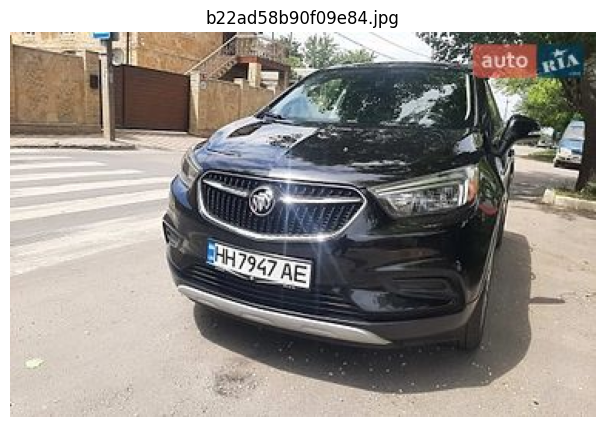

In [11]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

_df_preview = pd.read_csv(PAIRS_CSV).head(1)
_smoke_path = IMAGES_ROOT / _df_preview.iloc[0]['path_a']
_profile = process_image(_smoke_path)

print('detected:    ', _profile.detected, f"(conf={_profile.detection_conf:.2f})")
print('bbox:        ', _profile.bbox)
print('colour:      ', _profile.color)
print('embedding:   ', None if _profile.embedding is None else _profile.embedding.shape)
print('plates:      ', [p['text'] for p in _profile.plates])

_img = Image.open(_smoke_path)
plt.figure(figsize=(8,5)); plt.imshow(_img); plt.axis('off'); plt.title(_smoke_path.name); plt.show()

## 8. Run the analysis loop

Same logic as `pipe/analyze_dataset.py`, but inlined so progress is visible. Resumable via `--resume`-style check on existing CSV.

In [12]:
import csv, json
import numpy as np
from tqdm.auto import tqdm

CSV_FIELDS = [
    'path', 'vehicle_id', 'detected', 'detection_conf',
    'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2',
    'color_name', 'color_hex', 'color_share',
    'num_plates', 'plates', 'embedding_idx',
]

def collect_unique(pairs_csv):
    df = pd.read_csv(pairs_csv)
    sa = df[['path_a','vehicle_id_a']].rename(columns={'path_a':'path','vehicle_id_a':'vehicle_id'})
    sb = df[['path_b','vehicle_id_b']].rename(columns={'path_b':'path','vehicle_id_b':'vehicle_id'})
    return pd.concat([sa,sb], ignore_index=True).drop_duplicates('path').reset_index(drop=True)

def build_record(rel_path, vehicle_id, profile, emb_idx):
    rec = {f: '' for f in CSV_FIELDS}
    rec['path'] = rel_path
    rec['vehicle_id'] = vehicle_id
    rec['embedding_idx'] = emb_idx
    if profile is None:
        rec.update({'detected': False, 'detection_conf': 0.0, 'num_plates': 0, 'plates': '[]'})
        return rec
    rec['detected'] = profile.detected
    rec['detection_conf'] = round(profile.detection_conf, 4)
    if profile.bbox is not None:
        rec['bbox_x1'], rec['bbox_y1'], rec['bbox_x2'], rec['bbox_y2'] = profile.bbox
    if profile.color is not None:
        rec['color_name']  = profile.color['name']
        rec['color_hex']   = profile.color['hex']
        rec['color_share'] = round(profile.color['share'], 4)
    plates = [p['text'] for p in profile.plates]
    rec['num_plates'] = len(plates)
    rec['plates'] = json.dumps(plates, ensure_ascii=False)
    return rec

todo = collect_unique(PAIRS_CSV)
print(f'unique images: {len(todo)}')

# Resume: skip already-processed
done_paths = set()
existing_emb = None
if OUT_CSV.exists():
    prev = pd.read_csv(OUT_CSV)
    done_paths = set(prev['path'].astype(str))
    if OUT_EMB.exists():
        existing_emb = np.load(OUT_EMB)
    print(f'resuming — already done: {len(done_paths)}')

remaining = todo[~todo['path'].isin(done_paths)].reset_index(drop=True)
print(f'remaining to process: {len(remaining)}')

new_embeddings = []
base_idx = 0 if existing_emb is None else int(existing_emb.shape[0])
write_header = not OUT_CSV.exists()
mode = 'a' if OUT_CSV.exists() else 'w'

with open(OUT_CSV, mode, newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=CSV_FIELDS)
    if write_header:
        writer.writeheader()
    for _, row in tqdm(remaining.iterrows(), total=len(remaining), desc='analyzing'):
        rel = str(row['path'])
        ipath = IMAGES_ROOT / rel
        profile = None
        try:
            if ipath.exists():
                profile = process_image(ipath)
            else:
                print('[missing]', ipath)
        except Exception as e:
            print(f'[error] {rel}: {e}')
        emb = profile.embedding if (profile is not None and profile.embedding is not None) else np.zeros(256, dtype=np.float32)
        new_embeddings.append(emb.astype(np.float32))
        writer.writerow(build_record(rel, row['vehicle_id'], profile, base_idx + len(new_embeddings) - 1))
        f.flush()

new_arr = np.stack(new_embeddings) if new_embeddings else np.zeros((0,256), dtype=np.float32)
combined = np.concatenate([existing_emb, new_arr], axis=0) if (existing_emb is not None and existing_emb.shape[0] > 0) else new_arr
np.save(OUT_EMB, combined)
print(f'\n✓ wrote {OUT_CSV} ({combined.shape[0]} rows)')
print(f'✓ wrote {OUT_EMB} shape={combined.shape}')

unique images: 3482
remaining to process: 3482


analyzing:   0%|          | 0/3482 [00:00<?, ?it/s]

[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck detected
[vehicle] no car/bus/truck d

## 9. Quick sanity checks

In [13]:
results = pd.read_csv(OUT_CSV)
embeddings = np.load(OUT_EMB)

print('rows:', len(results))
print('emb: ', embeddings.shape)
print('detected rate: ', results['detected'].mean())
print('plate-found rate:', (results['num_plates'] > 0).mean())

print('\nTop colours:')
print(results['color_name'].value_counts().head(10))

print('\nSample rows:')
results.head(5)

rows: 3482
emb:  (3482, 256)
detected rate:  0.9497415278575532
plate-found rate: 0.6435956346927053

Top colours:
color_name
blue         2071
gray          367
silver        305
dark_gray     188
red           146
white          55
orange         44
magenta        37
cyan           31
green          23
Name: count, dtype: int64

Sample rows:


,path,vehicle_id,detected,detection_conf,bbox_x1,bbox_y1,bbox_x2,bbox_y2,color_name,color_hex,color_share,num_plates,plates,embedding_idx
0,images/b22ad58b90f09e84.jpg,44977551,True,0.8756,90.0,13.0,350.0,220.0,blue,#2D313B,0.3433,1,"[""H7947AE""]",0
1,images/d31563656f68d0dc.jpg,44976301,True,0.9400,2.0,83.0,800.0,525.0,blue,#375469,0.6558,0,[],1
2,images/610e186372556492.jpg,44977748,True,0.7369,87.0,26.0,289.0,201.0,blue,#171E29,0.3882,1,"[""KA8526TA""]",2
3,images/7439634173be8c42.jpg,44977497,True,0.6957,0.0,0.0,377.0,242.0,cyan,#22A5DD,0.5289,1,"[""AM8514YA""]",3
4,images/dc36ea7004f5868a.jpg,44976825,True,0.5781,108.0,213.0,764.0,600.0,red,#2D191A,0.3145,1,"[""BI7TI""]",4


## 10. Pair-level evaluation (ROC-AUC on the original pairs CSV)

For every pair in `pairs_*.csv`, look up the two embeddings and compute cosine similarity. Compare against the `label` column.

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve

pairs = pd.read_csv(PAIRS_CSV)
lookup = dict(zip(results['path'].astype(str), results['embedding_idx'].astype(int)))

sims, labels = [], []
missing = 0
for _, p in pairs.iterrows():
    ia = lookup.get(str(p['path_a']))
    ib = lookup.get(str(p['path_b']))
    if ia is None or ib is None:
        missing += 1
        continue
    va, vb = embeddings[ia], embeddings[ib]
    sims.append(float(va @ vb))
    labels.append(int(p['label']))

sims = np.asarray(sims); labels = np.asarray(labels)
print(f'pairs evaluated: {len(sims)}   missing (no embedding): {missing}')
print(f'positives: {(labels==1).sum()}   negatives: {(labels==0).sum()}')
print(f'ROC-AUC: {roc_auc_score(labels, sims):.4f}')
print(f'mean cos pos: {sims[labels==1].mean():.4f}   mean cos neg: {sims[labels==0].mean():.4f}')

# Best threshold via Youden's J
fpr, tpr, thr = roc_curve(labels, sims)
j = tpr - fpr
best = int(np.argmax(j))
print(f'best threshold = {thr[best]:.4f}   (TPR={tpr[best]:.3f}, FPR={fpr[best]:.3f})')

pairs evaluated: 1996   missing (no embedding): 0
positives: 1000   negatives: 996
ROC-AUC: 0.8254
mean cos pos: 0.7801   mean cos neg: 0.2543
best threshold = 0.7436   (TPR=0.773, FPR=0.219)


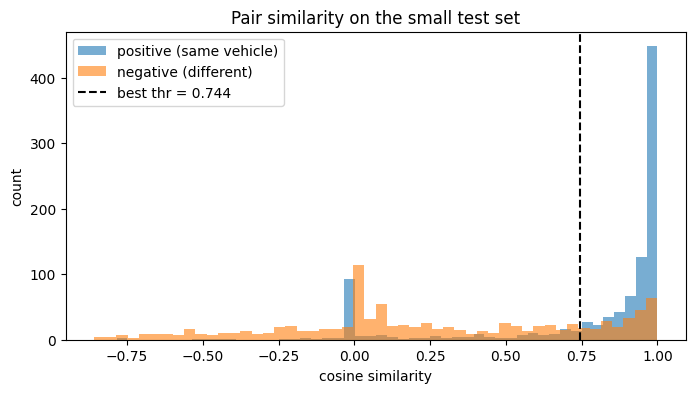

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(sims[labels==1], bins=50, alpha=0.6, label='positive (same vehicle)')
plt.hist(sims[labels==0], bins=50, alpha=0.6, label='negative (different)')
plt.axvline(thr[best], color='k', linestyle='--', label=f'best thr = {thr[best]:.3f}')
plt.yscale('log')
plt.xlabel('cosine similarity'); plt.ylabel('count'); plt.legend()
plt.title('Pair similarity on the small test set')
plt.show()